# Composite Lateral Variability Index
## A single scalar score per area derived from all five petrophysical properties

Four composite indices are computed, each with a different theoretical basis:

| Index | Abbreviation | Theoretical basis |
|-------|-------------|-------------------|
| Weighted Heterogeneity Index | WHI | Normalized CV aggregation |
| Multivariate Variogram Dispersion Score | MVDS | Spatial integral of variogram curves |
| PCA Total Spread Index | PTSI | Eigenvalue distribution of covariance matrix |
| Joint Entropy Score | JES | Multivariate Shannon information entropy |

Each index returns **one number per area**. Higher = more laterally variable.
All four are then fused into a single **Master Heterogeneity Index (MHI)**.


## 0. Setup & grid generation

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.optimize import curve_fit
from scipy.spatial.distance import pdist, squareform
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from itertools import product
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False,
                     'axes.spines.right': False, 'font.size': 10})

GRID  = 80
AREAS = ['Area A', 'Area B']
PROPS = ['Structure', 'Porosity', 'Isopach', 'Sw', 'GR']
COLORS = {'Area A': '#185FA5', 'Area B': '#993C1D'}

# Geological weights for WHI (reservoir-quality focused)
GEO_WEIGHTS = {'Structure': 0.10, 'Porosity': 0.30,
               'Isopach': 0.20,  'Sw': 0.25, 'GR': 0.15}


In [2]:
# ── Reproduce both area grids ─────────────────────────────────────────────────
def bf_A(nx, ny):
    return (0.42*np.sin(nx*np.pi*1.2+0.3)*np.cos(ny*np.pi*0.9+0.5)
           +0.28*np.sin(nx*np.pi*2.1+1.1)*np.sin(ny*np.pi*1.7+0.8)
           +0.18*np.cos(nx*np.pi*3.0+0.7)*np.cos(ny*np.pi*2.5+1.3)
           +0.08*np.sin(nx*np.pi*4.0+2.0)*np.cos(ny*np.pi*3.8+0.4)
           +0.14*(1-np.exp(-((nx-0.30)**2+(ny-0.25)**2)/0.015))
           -0.11*np.exp(-((nx-0.72)**2+(ny-0.68)**2)/0.012))

def bf_B(nx, ny):
    return (0.35*np.sin(nx*np.pi*2.5+0.8)*np.cos(ny*np.pi*1.8+1.2)
           +0.22*np.cos(nx*np.pi*4.2+0.4)*np.sin(ny*np.pi*3.1+0.7)
           +0.28*np.sin(nx*np.pi*1.1+1.5)*np.cos(ny*np.pi*2.4+0.3)
           +0.15*np.cos(nx*np.pi*5.5+2.1)*np.cos(ny*np.pi*4.0+1.8)
           +0.18*np.exp(-((nx-0.55)**2+(ny-0.40)**2)/0.018)
           -0.14*np.exp(-((nx-0.22)**2+(ny-0.75)**2)/0.010)
           -0.10*np.exp(-((nx-0.78)**2+(ny-0.20)**2)/0.013))

x = np.linspace(0, 1, GRID+1)
NX, NY = np.meshgrid(x, x)
BFA, BFB = bf_A(NX, NY), bf_B(NX, NY)

def mk(arr, lo, hi): return np.clip(arr, lo, hi)

grids = {
    'Area A': {
        'Structure': mk(7500+900*np.sin(NX*np.pi*1.2+0.3)*np.cos(NY*np.pi*0.9+0.5)
                        +600*np.sin(NX*np.pi*2.1+1.1)*np.sin(NY*np.pi*1.7+0.8)
                        +400*np.cos(NX*np.pi*3.0+0.7)*np.cos(NY*np.pi*2.5+1.3)
                        +200*np.sin(NX*np.pi*4.0+2.0)*np.cos(NY*np.pi*3.8+0.4)
                        +300*(1-np.exp(-((NX-0.30)**2+(NY-0.25)**2)/0.015))
                        -250*np.exp(-((NX-0.72)**2+(NY-0.68)**2)/0.012), 7500, 10000),
        'Porosity': mk(0.075+0.025*BFA, 0.05, 0.10),
        'Isopach':  mk(40+20*(-BFA*0.9+0.05*np.sin(NX*5)*np.cos(NY*4)), 20, 60),
        'Sw':       mk(0.40-0.18*BFA+0.04*np.cos(NX*6+NY*4), 0.20, 0.60),
        'GR':       mk(75+42*(BFA*0.8+0.12*np.sin(NX*7+1)*np.sin(NY*5+0.5)), 30, 120),
    },
    'Area B': {
        'Structure': mk(8800+600*np.sin(NX*np.pi*2.5+0.8)*np.cos(NY*np.pi*1.8+1.2)
                        +400*np.cos(NX*np.pi*4.2+0.4)*np.sin(NY*np.pi*3.1+0.7)
                        +300*np.exp(-((NX-0.55)**2+(NY-0.40)**2)/0.018)
                        -200*np.exp(-((NX-0.22)**2+(NY-0.75)**2)/0.010), 7800, 9800),
        'Porosity': mk(0.10+0.04*BFB+0.008*np.cos(NX*8)*np.sin(NY*6), 0.06, 0.14),
        'Isopach':  mk(40+18*(BFB*0.7+0.15*np.sin(NX*9+1)*np.cos(NY*7+2)), 20, 60),
        'Sw':       mk(0.35-0.16*BFB+0.06*np.sin(NX*7+NY*5+0.5)+0.03*np.cos(NX*11), 0.15, 0.55),
        'GR':       mk(78+48*(BFB*0.6+0.20*np.sin(NX*10+2)*np.cos(NY*8+1)+0.08*np.sin(NX*15)), 25, 130),
    }
}

# Flatten to node-x-property matrix for each area
X = {area: np.column_stack([grids[area][p].ravel() for p in PROPS]) for area in AREAS}
X_sc = {area: StandardScaler().fit_transform(X[area]) for area in AREAS}

print("Grids ready. Node count per area:", X['Area A'].shape[0])
print("Property shapes:", {p: grids['Area A'][p].shape for p in PROPS})


Grids ready. Node count per area: 6561
Property shapes: {'Structure': (81, 81), 'Porosity': (81, 81), 'Isopach': (81, 81), 'Sw': (81, 81), 'GR': (81, 81)}


---
## Index 1 — Weighted Heterogeneity Index (WHI)

**Formula:**

$$WHI = \sum_{i=1}^{5} w_i \cdot \widetilde{CV}_i$$

where $\widetilde{CV}_i$ is the coefficient of variation of property $i$ normalized across both areas
so that the maximum across areas = 1, and $w_i$ are geologically motivated weights
(Porosity 0.30, Sw 0.25, Isopach 0.20, GR 0.15, Structure 0.10).

**Interpretation:** Higher WHI = greater average lateral spread of property values,
weighted by reservoir engineering importance.


In [3]:
# ── Step 1: raw CV per property per area ─────────────────────────────────────
cv_raw = {}
for area in AREAS:
    cv_raw[area] = {}
    for p in PROPS:
        g = grids[area][p].ravel()
        cv_raw[area][p] = g.std() / np.abs(g.mean())

cv_df = pd.DataFrame(cv_raw).T
print("Raw CV values:")
print(cv_df.round(5).to_string())

# ── Step 2: normalize CV per property across the two areas ────────────────────
cv_norm = {area: {} for area in AREAS}
for p in PROPS:
    vals = [cv_raw[a][p] for a in AREAS]
    lo, hi = min(vals), max(vals)
    for area in AREAS:
        cv_norm[area][p] = (cv_raw[area][p] - lo) / (hi - lo + 1e-12)

# ── Step 3: weighted sum → WHI ────────────────────────────────────────────────
WHI = {}
for area in AREAS:
    WHI[area] = sum(GEO_WEIGHTS[p] * cv_norm[area][p] for p in PROPS)

print(" Normalized CV values:")
print(pd.DataFrame(cv_norm).T.round(4).to_string())
print(f" WHI  ->  Area A: {WHI['Area A']:.4f}  |  Area B: {WHI['Area B']:.4f}")
print(f"=> {'Area B' if WHI['Area B'] > WHI['Area A'] else 'Area A'} is more heterogeneous (WHI)")


Raw CV values:
        Structure  Porosity  Isopach       Sw       GR
Area A    0.04839   0.08012  0.10971  0.12541  0.12775
Area B    0.04470   0.10620  0.09616  0.20497  0.11853
 Normalized CV values:
        Structure  Porosity  Isopach   Sw   GR
Area A        1.0       0.0      1.0  0.0  1.0
Area B        0.0       1.0      0.0  1.0  0.0
 WHI  ->  Area A: 0.4500  |  Area B: 0.5500
=> Area B is more heterogeneous (WHI)


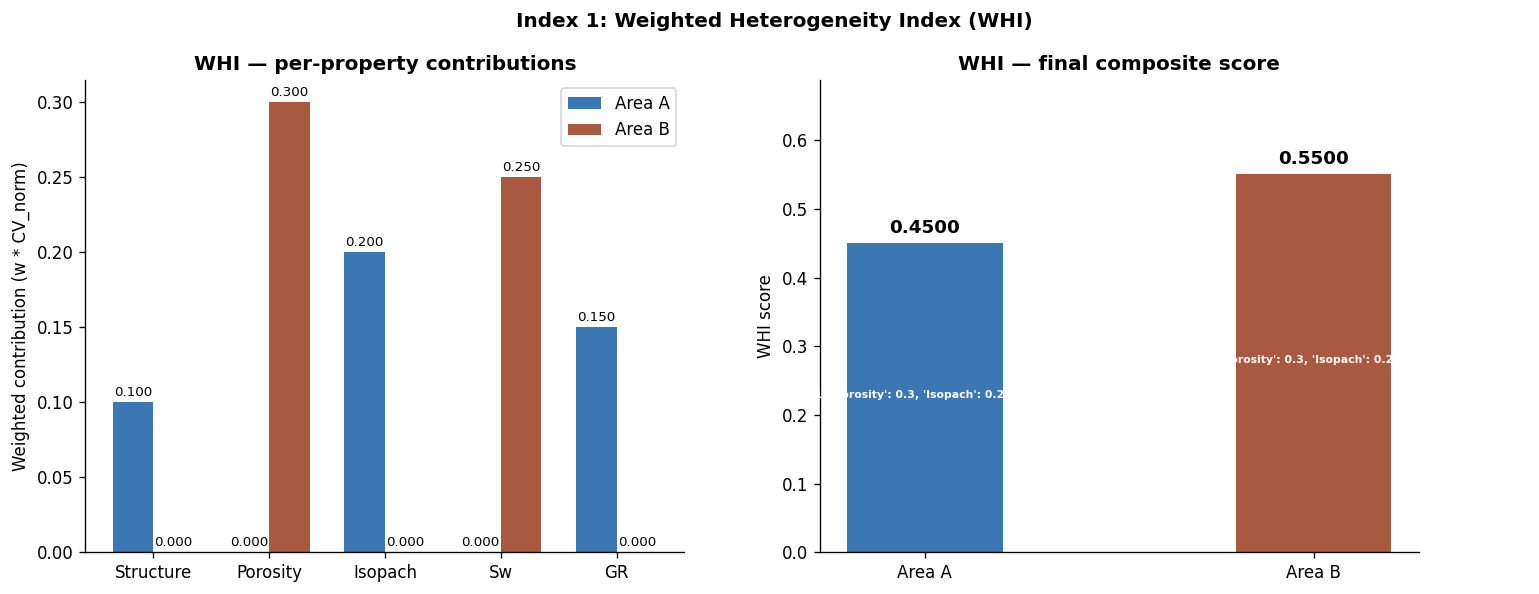

In [4]:
# ── WHI breakdown waterfall chart ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Contribution per property per area
ax = axes[0]
x_pos = np.arange(len(PROPS))
width = 0.35
contrib_A = [GEO_WEIGHTS[p]*cv_norm['Area A'][p] for p in PROPS]
contrib_B = [GEO_WEIGHTS[p]*cv_norm['Area B'][p] for p in PROPS]
bA = ax.bar(x_pos-width/2, contrib_A, width, label='Area A', color=COLORS['Area A'], alpha=0.85)
bB = ax.bar(x_pos+width/2, contrib_B, width, label='Area B', color=COLORS['Area B'], alpha=0.85)
ax.bar_label(bA, fmt='%.3f', padding=2, fontsize=8)
ax.bar_label(bB, fmt='%.3f', padding=2, fontsize=8)
ax.set_xticks(x_pos); ax.set_xticklabels(PROPS)
ax.set_ylabel('Weighted contribution (w * CV_norm)')
ax.set_title('WHI — per-property contributions', fontweight='bold')
ax.legend()

# Final WHI scores
ax2 = axes[1]
whi_vals = [WHI[a] for a in AREAS]
bars = ax2.bar(AREAS, whi_vals, color=[COLORS[a] for a in AREAS], alpha=0.85, width=0.4)
ax2.bar_label(bars, fmt='%.4f', padding=4, fontsize=11, fontweight='bold')
ax2.set_ylabel('WHI score')
ax2.set_title('WHI — final composite score', fontweight='bold')
ax2.set_ylim(0, max(whi_vals)*1.25)
for i, (area, v) in enumerate(zip(AREAS, whi_vals)):
    ax2.text(i, v*0.5, f'w={str({p: round(GEO_WEIGHTS[p],2) for p in PROPS})[1:-1]}',
             ha='center', fontsize=6.5, color='white', fontweight='bold')

plt.suptitle('Index 1: Weighted Heterogeneity Index (WHI)', fontweight='bold')
plt.tight_layout()
plt.savefig('idx1_WHI.png', dpi=130, bbox_inches='tight')
plt.show()


---
## Index 2 — Multivariate Variogram Dispersion Score (MVDS)

**Formula:**

$$MVDS = \frac{1}{N_p} \sum_{i=1}^{N_p} \int_0^{h_{max}} \frac{\gamma_i(h)}{sill_i} \, dh$$

The integral of the normalized variogram captures both the spatial rate of change (range)
and the total variance (sill) in a single area measure.
A short-range, high-sill variogram integrates to a larger value = more spatially dispersed.
We approximate the integral numerically using the trapezoidal rule.

**Interpretation:** Higher MVDS = property values are more dissimilar at short distances
= patchier spatial structure.


In [5]:
def exp_variogram(grid, n_lags=20, max_lag_frac=0.45, n_sample=2000, seed=42):
    flat = grid.ravel()
    rng  = np.random.default_rng(seed)
    idx  = rng.choice(len(flat), size=min(n_sample, len(flat)), replace=False)
    ri, ci = np.unravel_index(idx, grid.shape)
    coords = np.stack([ri, ci], axis=1).astype(float)
    vals   = flat[idx]
    dists  = squareform(pdist(coords))
    max_d  = dists.max() * max_lag_frac
    lags   = np.linspace(0, max_d, n_lags+1)
    gamma, counts = [], []
    for lo, hi in zip(lags[:-1], lags[1:]):
        mask = (dists > lo) & (dists <= hi)
        if mask.sum() < 5:
            gamma.append(np.nan); counts.append(0); continue
        ii, jj = np.where(mask)
        gamma.append(0.5 * np.mean((vals[ii]-vals[jj])**2))
        counts.append(mask.sum())
    centers = (lags[:-1]+lags[1:])/2
    return centers, np.array(gamma), np.array(counts)

def spherical(h, nugget, sill, rang):
    h = np.asarray(h, float)
    return np.where(h <= rang,
                    nugget+(sill-nugget)*(1.5*(h/rang)-0.5*(h/rang)**3), sill)

# Compute variogram integrals
vario_integrals = {area: {} for area in AREAS}
vario_fits      = {area: {} for area in AREAS}

for area in AREAS:
    for prop in PROPS:
        h, gamma, _ = exp_variogram(grids[area][prop])
        valid = ~np.isnan(gamma)
        try:
            p0 = [gamma[valid].min()*0.1, gamma[valid].max(), h[valid].max()*0.5]
            popt, _ = curve_fit(spherical, h[valid], gamma[valid], p0=p0,
                                maxfev=8000, bounds=([0,0,1],[np.inf,np.inf,np.inf]))
            nugget, sill, rang = popt
            # Evaluate fitted variogram on fine grid
            h_fine    = np.linspace(0, h[valid].max(), 500)
            gamma_fit = spherical(h_fine, *popt)
            # Normalize by sill and integrate (trapezoidal)
            gamma_norm = gamma_fit / (sill + 1e-12)
            integral   = np.trapezoid(gamma_norm, h_fine)
            vario_integrals[area][prop] = integral
            vario_fits[area][prop] = dict(h=h, gamma=gamma, valid=valid,
                                          popt=popt, h_fine=h_fine,
                                          gamma_fit=gamma_fit, fitted=True)
        except Exception:
            vario_integrals[area][prop] = np.nan
            vario_fits[area][prop] = dict(h=h, gamma=gamma, valid=valid, fitted=False)

# Normalize integrals across areas and average -> MVDS
integ_df = pd.DataFrame(vario_integrals).T
print("Variogram integrals (sum under normalized curve):")
print(integ_df.round(4).to_string())

MVDS = {}
for area in AREAS:
    vals = [vario_integrals[area][p] for p in PROPS if not np.isnan(vario_integrals[area][p])]
    MVDS[area] = np.mean(vals)

# Normalize MVDS to [0,1]
lo, hi = min(MVDS.values()), max(MVDS.values())
MVDS_norm = {a: (v-lo)/(hi-lo+1e-12) for a, v in MVDS.items()}

print(f" Raw MVDS  ->  Area A: {MVDS['Area A']:.4f}  |  Area B: {MVDS['Area B']:.4f}")
print(f"=> {'Area B' if MVDS['Area B'] > MVDS['Area A'] else 'Area A'} is more spatially dispersed (MVDS)")


Variogram integrals (sum under normalized curve):
        Structure  Porosity  Isopach       Sw       GR
Area A    34.7520   39.8380  32.5934  12.7443  32.0555
Area B    36.5384   37.2018  36.7188  34.8149  39.0720
 Raw MVDS  ->  Area A: 30.3966  |  Area B: 36.8692
=> Area B is more spatially dispersed (MVDS)


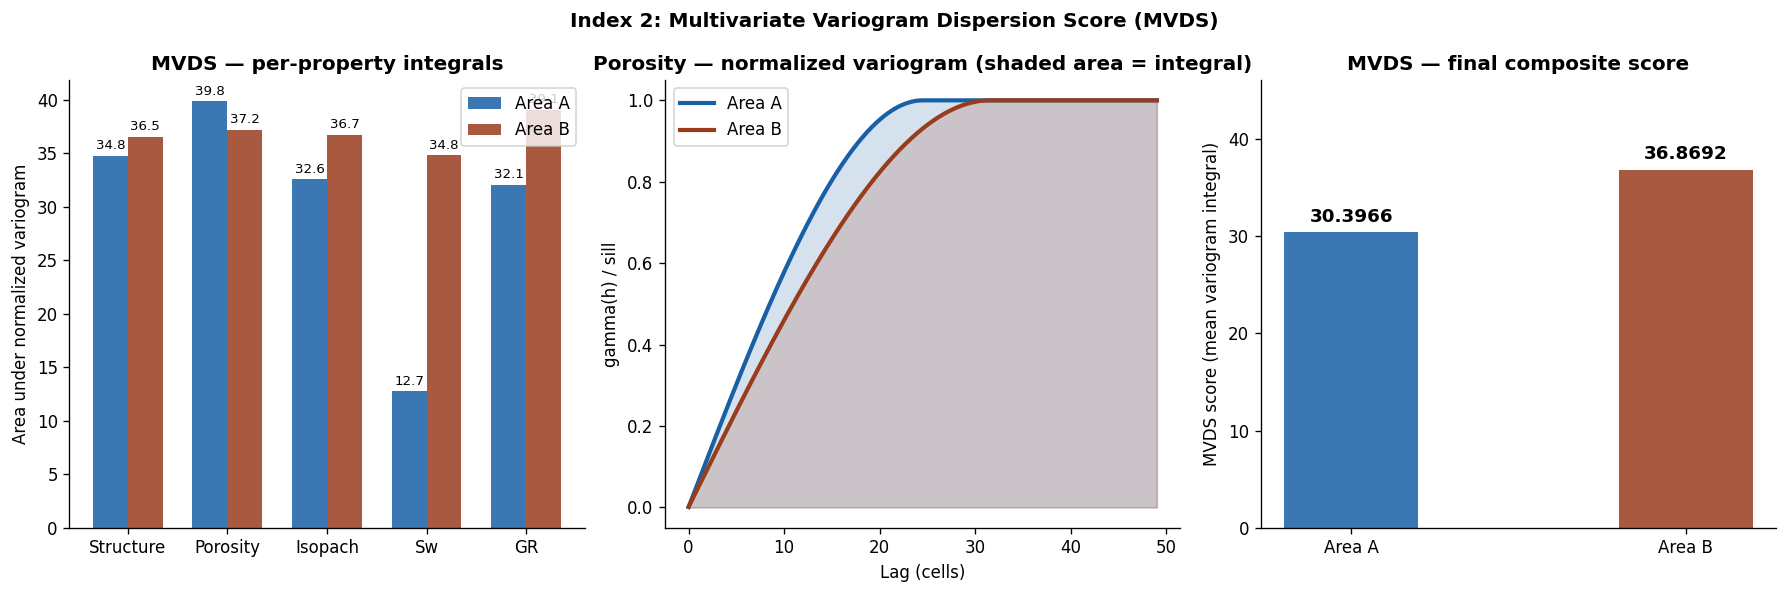

In [6]:
# ── Visualize variogram integrals ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Integral per property
ax = axes[0]
x_pos = np.arange(len(PROPS)); width = 0.35
bA = ax.bar(x_pos-width/2, [vario_integrals['Area A'][p] for p in PROPS],
            width, label='Area A', color=COLORS['Area A'], alpha=0.85)
bB = ax.bar(x_pos+width/2, [vario_integrals['Area B'][p] for p in PROPS],
            width, label='Area B', color=COLORS['Area B'], alpha=0.85)
ax.bar_label(bA, fmt='%.1f', padding=2, fontsize=8)
ax.bar_label(bB, fmt='%.1f', padding=2, fontsize=8)
ax.set_xticks(x_pos); ax.set_xticklabels(PROPS)
ax.set_ylabel('Area under normalized variogram')
ax.set_title('MVDS — per-property integrals', fontweight='bold')
ax.legend()

# Example normalized variograms for Porosity
ax2 = axes[1]
for area in AREAS:
    vf = vario_fits[area]['Porosity']
    if vf['fitted']:
        h_fine = vf['h_fine']
        sill   = vf['popt'][1]
        ax2.plot(h_fine, vf['gamma_fit']/sill, linewidth=2.5,
                 label=area, color=COLORS[area])
        ax2.fill_between(h_fine, 0, vf['gamma_fit']/sill,
                         alpha=0.18, color=COLORS[area])
ax2.set_xlabel('Lag (cells)'); ax2.set_ylabel('gamma(h) / sill')
ax2.set_title('Porosity — normalized variogram (shaded area = integral)', fontweight='bold')
ax2.legend()

# MVDS final scores
ax3 = axes[2]
mvds_vals = [MVDS[a] for a in AREAS]
bars = ax3.bar(AREAS, mvds_vals, color=[COLORS[a] for a in AREAS], alpha=0.85, width=0.4)
ax3.bar_label(bars, fmt='%.4f', padding=4, fontsize=11, fontweight='bold')
ax3.set_ylabel('MVDS score (mean variogram integral)')
ax3.set_title('MVDS — final composite score', fontweight='bold')
ax3.set_ylim(0, max(mvds_vals)*1.25)

plt.suptitle('Index 2: Multivariate Variogram Dispersion Score (MVDS)', fontweight='bold')
plt.tight_layout()
plt.savefig('idx2_MVDS.png', dpi=130, bbox_inches='tight')
plt.show()


---
## Index 3 — PCA Total Spread Index (PTSI)

**Formula:**

$$PTSI = 1 - \frac{\lambda_1}{\sum_{i=1}^{5} \lambda_i}$$

where $\lambda_i$ are the eigenvalues of the standardized covariance matrix (= PCA explained variances).

- If **PC1 dominates** (λ₁/Σλᵢ → 1): all properties vary together along one direction
  → correlated, simpler heterogeneity → **PTSI → 0**
- If variance is **spread evenly** across all PCs (λ₁/Σλᵢ → 1/5 = 0.2): properties
  vary independently in many directions → complex, multidimensional heterogeneity → **PTSI → 0.8**

**Interpretation:** Higher PTSI = the five properties vary in more independent spatial modes
= geologically more complex area.


In [7]:
pca_results = {}
PTSI = {}

for area in AREAS:
    pca = PCA(n_components=5)
    pca.fit(X_sc[area])
    evr = pca.explained_variance_ratio_   # already normalized (sum=1)
    ptsi = 1 - evr[0]                     # = 1 - lambda1/sum(lambda)
    pca_results[area] = dict(pca=pca, evr=evr, ptsi=ptsi)
    PTSI[area] = ptsi

    cumev = np.cumsum(evr)
    n90   = int(np.searchsorted(cumev, 0.90)) + 1
    print(f"{area}:")
    print(f"  Eigenvalue shares: {np.round(evr*100,1)}")
    print(f"  PC1 dominance:     {evr[0]*100:.1f}%")
    print(f"  PTSI:              {ptsi:.4f}")
    print(f"  PCs for 90%:       {n90}")
    print()

print(f"PTSI  ->  Area A: {PTSI['Area A']:.4f}  |  Area B: {PTSI['Area B']:.4f}")
print(f"=> {'Area B' if PTSI['Area B'] > PTSI['Area A'] else 'Area A'} has more multidimensional heterogeneity (PTSI)")


Area A:
  Eigenvalue shares: [90.5  6.9  2.1  0.4  0.1]
  PC1 dominance:     90.5%
  PTSI:              0.0950
  PCs for 90%:       1

Area B:
  Eigenvalue shares: [75.5 11.9  5.1  4.8  2.7]
  PC1 dominance:     75.5%
  PTSI:              0.2451
  PCs for 90%:       3

PTSI  ->  Area A: 0.0950  |  Area B: 0.2451
=> Area B has more multidimensional heterogeneity (PTSI)


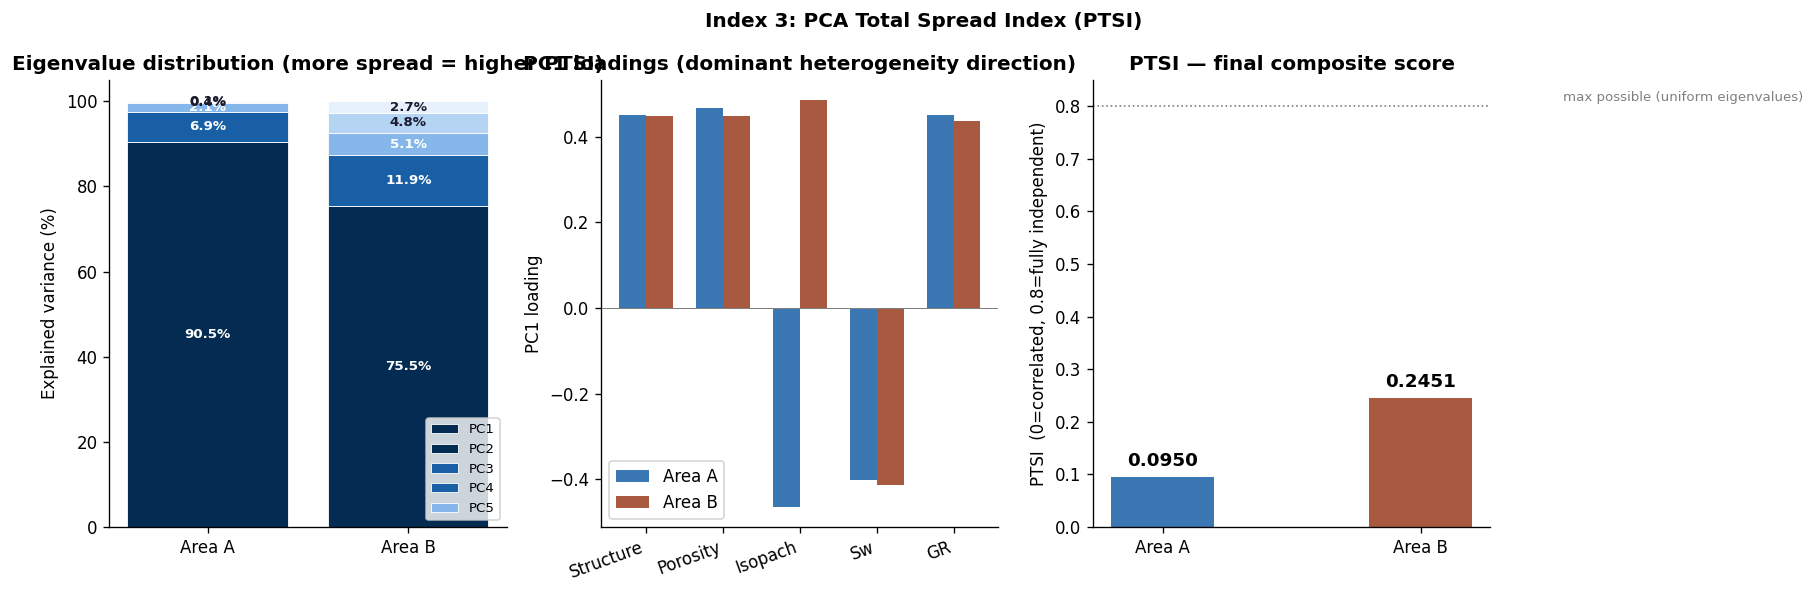

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Eigenvalue distribution (stacked area)
ax = axes[0]
pc_labels = [f'PC{i+1}' for i in range(5)]
bottom_A = 0.0; bottom_B = 0.0
palette = ['#042C53','#185FA5','#85B7EB','#B5D4F4','#E6F1FB']
for i in range(5):
    va = pca_results['Area A']['evr'][i]*100
    vb = pca_results['Area B']['evr'][i]*100
    ax.bar(0, va, bottom=bottom_A, color=palette[i], edgecolor='white',
           linewidth=0.5, label=pc_labels[i] if 0==0 else '')
    ax.bar(1, vb, bottom=bottom_B, color=palette[i], edgecolor='white', linewidth=0.5)
    ax.text(0, bottom_A+va/2, f'{va:.1f}%', ha='center', va='center',
            fontsize=8, color='white' if i < 3 else '#1a1a2e', fontweight='bold')
    ax.text(1, bottom_B+vb/2, f'{vb:.1f}%', ha='center', va='center',
            fontsize=8, color='white' if i < 3 else '#1a1a2e', fontweight='bold')
    bottom_A += va; bottom_B += vb
ax.set_xticks([0,1]); ax.set_xticklabels(AREAS)
ax.set_ylabel('Explained variance (%)')
ax.set_title('Eigenvalue distribution (more spread = higher PTSI)', fontweight='bold')
ax.legend(pc_labels, loc='lower right', fontsize=8)

# PC1 loadings
ax2 = axes[1]
x_pos = np.arange(len(PROPS)); width = 0.35
for i, area in enumerate(AREAS):
    loads = pca_results[area]['pca'].components_[0]
    ax2.bar(x_pos+(i-0.5)*width, loads, width, label=area,
            color=COLORS[area], alpha=0.85)
ax2.axhline(0, color='gray', linewidth=0.6)
ax2.set_xticks(x_pos); ax2.set_xticklabels(PROPS, rotation=20, ha='right')
ax2.set_ylabel('PC1 loading'); ax2.legend()
ax2.set_title('PC1 loadings (dominant heterogeneity direction)', fontweight='bold')

# PTSI final scores
ax3 = axes[2]
ptsi_vals = [PTSI[a] for a in AREAS]
bars = ax3.bar(AREAS, ptsi_vals, color=[COLORS[a] for a in AREAS], alpha=0.85, width=0.4)
ax3.bar_label(bars, fmt='%.4f', padding=4, fontsize=11, fontweight='bold')
ax3.set_ylabel('PTSI  (0=correlated, 0.8=fully independent)')
ax3.set_title('PTSI — final composite score', fontweight='bold')
ax3.set_ylim(0, 0.85)
ax3.axhline(0.8, color='gray', linestyle=':', linewidth=1)
ax3.text(1.55, 0.81, 'max possible (uniform eigenvalues)', fontsize=8, color='gray')

plt.suptitle('Index 3: PCA Total Spread Index (PTSI)', fontweight='bold')
plt.tight_layout()
plt.savefig('idx3_PTSI.png', dpi=130, bbox_inches='tight')
plt.show()


---
## Index 4 — Joint Entropy Score (JES)

**Formula:**

$$JES = -\sum_{b_1,...,b_5} p(b_1,...,b_5) \log_2 p(b_1,...,b_5)$$

Each of the five properties is discretized into $k$ equal-frequency bins at every grid node.
The joint probability distribution over all 5-bin combinations is computed from the node population,
and Shannon entropy is calculated over this joint distribution.

- **Maximum possible JES** = $5 \log_2 k$ (all bin combinations equally likely = fully chaotic)
- **Minimum JES** = 0 (all nodes fall in the same bin combination = perfectly uniform area)

We report JES normalized by its theoretical maximum so it lies in [0, 1].

**Interpretation:** Higher JES = the five properties jointly explore more of their
multivariate state space = richer, more unpredictable geological variation.


In [9]:
def joint_entropy_score(X_mat, n_bins=5):
    """
    Compute normalized multivariate Shannon entropy over the joint distribution
    of all 5 properties discretized into n_bins equal-frequency bins each.

    Parameters
    ----------
    X_mat : ndarray of shape (n_nodes, n_props)
    n_bins : int  — number of bins per property

    Returns
    -------
    jes_norm : float in [0, 1]
    jes_raw  : float  (bits)
    max_jes  : float  (bits) — 5 * log2(n_bins)
    counts   : dict  — joint bin combination -> count
    """
    n_nodes, n_props = X_mat.shape

    # Discretize each property into equal-frequency bins (quantile-based)
    binned = np.zeros_like(X_mat, dtype=int)
    for j in range(n_props):
        quantiles = np.linspace(0, 100, n_bins+1)
        edges     = np.percentile(X_mat[:, j], quantiles)
        edges[0] -= 1e-10; edges[-1] += 1e-10
        binned[:, j] = np.digitize(X_mat[:, j], edges[1:-1])

    # Count joint combinations
    combo_counts = {}
    for row in binned:
        key = tuple(row)
        combo_counts[key] = combo_counts.get(key, 0) + 1

    # Shannon entropy
    total  = sum(combo_counts.values())
    probs  = np.array(list(combo_counts.values())) / total
    jes_raw = -np.sum(probs * np.log2(probs + 1e-12))

    # Theoretical maximum = log2(n_bins^n_props)
    max_jes  = n_props * np.log2(n_bins)
    jes_norm = jes_raw / max_jes

    return jes_norm, jes_raw, max_jes, combo_counts

JES = {}
JES_raw = {}
JES_max = {}
combo_counts_all = {}

for area in AREAS:
    jes_norm, jes_raw, max_jes, counts = joint_entropy_score(X[area], n_bins=5)
    JES[area]          = jes_norm
    JES_raw[area]      = jes_raw
    JES_max[area]      = max_jes
    combo_counts_all[area] = counts

    n_occupied = len(counts)
    n_possible = 5**5    # 5 bins ^ 5 properties
    print(f"{area}:")
    print(f"  JES raw:          {jes_raw:.4f} bits")
    print(f"  JES normalized:   {jes_norm:.4f}  (max possible = {max_jes:.2f} bits)")
    print(f"  Joint bins used:  {n_occupied} / {n_possible} ({n_occupied/n_possible*100:.1f}%)")
    print()

print(f"JES  ->  Area A: {JES['Area A']:.4f}  |  Area B: {JES['Area B']:.4f}")
print(f"=> {'Area B' if JES['Area B'] > JES['Area A'] else 'Area A'} explores more joint state space (JES)")


Area A:
  JES raw:          5.3801 bits
  JES normalized:   0.4634  (max possible = 11.61 bits)
  Joint bins used:  154 / 3125 (4.9%)

Area B:
  JES raw:          8.0816 bits
  JES normalized:   0.6961  (max possible = 11.61 bits)
  Joint bins used:  573 / 3125 (18.3%)

JES  ->  Area A: 0.4634  |  Area B: 0.6961
=> Area B explores more joint state space (JES)


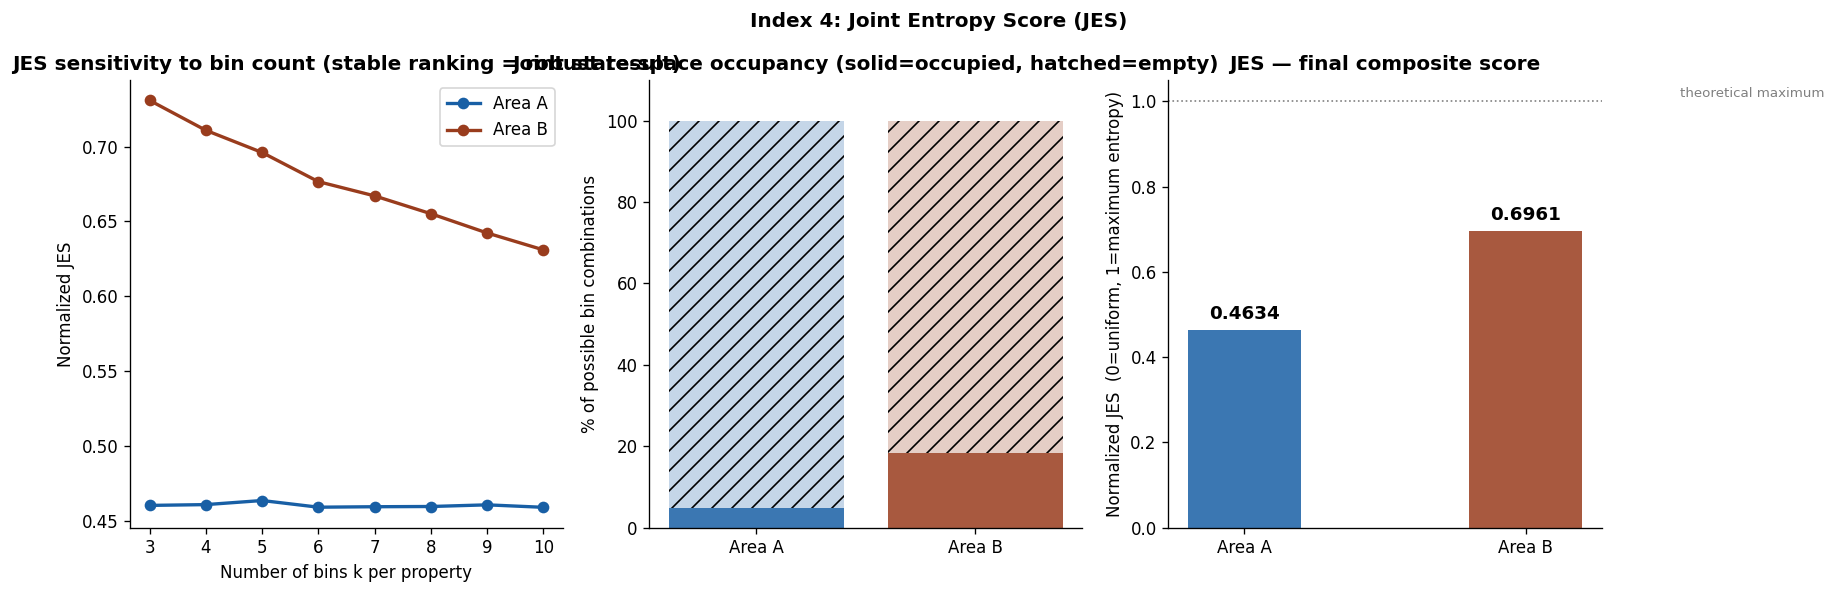

In [10]:
# ── JES sensitivity to n_bins ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Sensitivity analysis
ax = axes[0]
bin_range = range(3, 11)
jes_sens = {area: [] for area in AREAS}
for k in bin_range:
    for area in AREAS:
        jes_n, _, _, _ = joint_entropy_score(X[area], n_bins=k)
        jes_sens[area].append(jes_n)

for area in AREAS:
    ax.plot(list(bin_range), jes_sens[area], 'o-', label=area,
            color=COLORS[area], linewidth=2, markersize=6)
ax.set_xlabel('Number of bins k per property')
ax.set_ylabel('Normalized JES')
ax.set_title('JES sensitivity to bin count (stable ranking = robust result)', fontweight='bold')
ax.legend()

# Joint state-space occupancy (Venn-style bar)
ax2 = axes[1]
n_poss = 5**5
for i, area in enumerate(AREAS):
    n_occ = len(combo_counts_all[area])
    n_empty = n_poss - n_occ
    ax2.bar(i, n_occ/n_poss*100, color=COLORS[area], alpha=0.85, label='Occupied')
    ax2.bar(i, n_empty/n_poss*100, bottom=n_occ/n_poss*100,
            color=COLORS[area], alpha=0.25, hatch='//')
ax2.set_xticks([0,1]); ax2.set_xticklabels(AREAS)
ax2.set_ylabel('% of possible bin combinations')
ax2.set_title('Joint state-space occupancy (solid=occupied, hatched=empty)', fontweight='bold')
ax2.set_ylim(0, 110)

# JES final scores
ax3 = axes[2]
jes_vals = [JES[a] for a in AREAS]
bars = ax3.bar(AREAS, jes_vals, color=[COLORS[a] for a in AREAS], alpha=0.85, width=0.4)
ax3.bar_label(bars, fmt='%.4f', padding=4, fontsize=11, fontweight='bold')
ax3.set_ylabel('Normalized JES  (0=uniform, 1=maximum entropy)')
ax3.set_title('JES — final composite score', fontweight='bold')
ax3.set_ylim(0, 1.05)
ax3.axhline(1.0, color='gray', linestyle=':', linewidth=1)
ax3.text(1.55, 1.01, 'theoretical maximum', fontsize=8, color='gray')

plt.suptitle('Index 4: Joint Entropy Score (JES)', fontweight='bold')
plt.tight_layout()
plt.savefig('idx4_JES.png', dpi=130, bbox_inches='tight')
plt.show()


---
## Master Heterogeneity Index (MHI)

All four indices are normalized to [0, 1] across the two areas and averaged:

$$MHI = \frac{1}{4}(\widetilde{WHI} + \widetilde{MVDS} + \widetilde{PTSI} + \widetilde{JES})$$

This fuses the four complementary perspectives into a single final scalar.
Because each index measures a fundamentally different aspect of heterogeneity,
their average is more robust than any single index alone.


In [11]:
def norm2(d):
    """Normalize a dict of two values to [0,1]."""
    lo, hi = min(d.values()), max(d.values())
    span = hi - lo + 1e-12
    return {k: (v-lo)/span for k, v in d.items()}

WHI_n  = norm2(WHI)
MVDS_n = norm2(MVDS)
PTSI_n = norm2(PTSI)
JES_n  = norm2(JES)

MHI = {}
for area in AREAS:
    MHI[area] = np.mean([WHI_n[area], MVDS_n[area], PTSI_n[area], JES_n[area]])

# ── Summary table ─────────────────────────────────────────────────────────────
summary = pd.DataFrame({
    'WHI (raw)':  {a: round(WHI[a], 4)  for a in AREAS},
    'MVDS (raw)': {a: round(MVDS[a], 4) for a in AREAS},
    'PTSI (raw)': {a: round(PTSI[a], 4) for a in AREAS},
    'JES (raw)':  {a: round(JES[a], 4)  for a in AREAS},
    'WHI (norm)':  {a: round(WHI_n[a], 4)  for a in AREAS},
    'MVDS (norm)': {a: round(MVDS_n[a], 4) for a in AREAS},
    'PTSI (norm)': {a: round(PTSI_n[a], 4) for a in AREAS},
    'JES (norm)':  {a: round(JES_n[a], 4)  for a in AREAS},
    'MHI':  {a: round(MHI[a], 4)  for a in AREAS},
}).T
summary.index.name = 'Index'

print("=" * 60)
print("COMPOSITE LATERAL VARIABILITY SCORECARD")
print("=" * 60)
print(summary.to_string())
print()
winner = max(MHI, key=MHI.get)
print(f"MHI  ->  Area A: {MHI['Area A']:.4f}  |  Area B: {MHI['Area B']:.4f}")
print(f"=> {winner} is overall MORE laterally heterogeneous.")


COMPOSITE LATERAL VARIABILITY SCORECARD
              Area A   Area B
Index                        
WHI (raw)     0.4500   0.5500
MVDS (raw)   30.3966  36.8692
PTSI (raw)    0.0950   0.2451
JES (raw)     0.4634   0.6961
WHI (norm)    0.0000   1.0000
MVDS (norm)   0.0000   1.0000
PTSI (norm)   0.0000   1.0000
JES (norm)    0.0000   1.0000
MHI           0.0000   1.0000

MHI  ->  Area A: 0.0000  |  Area B: 1.0000
=> Area B is overall MORE laterally heterogeneous.


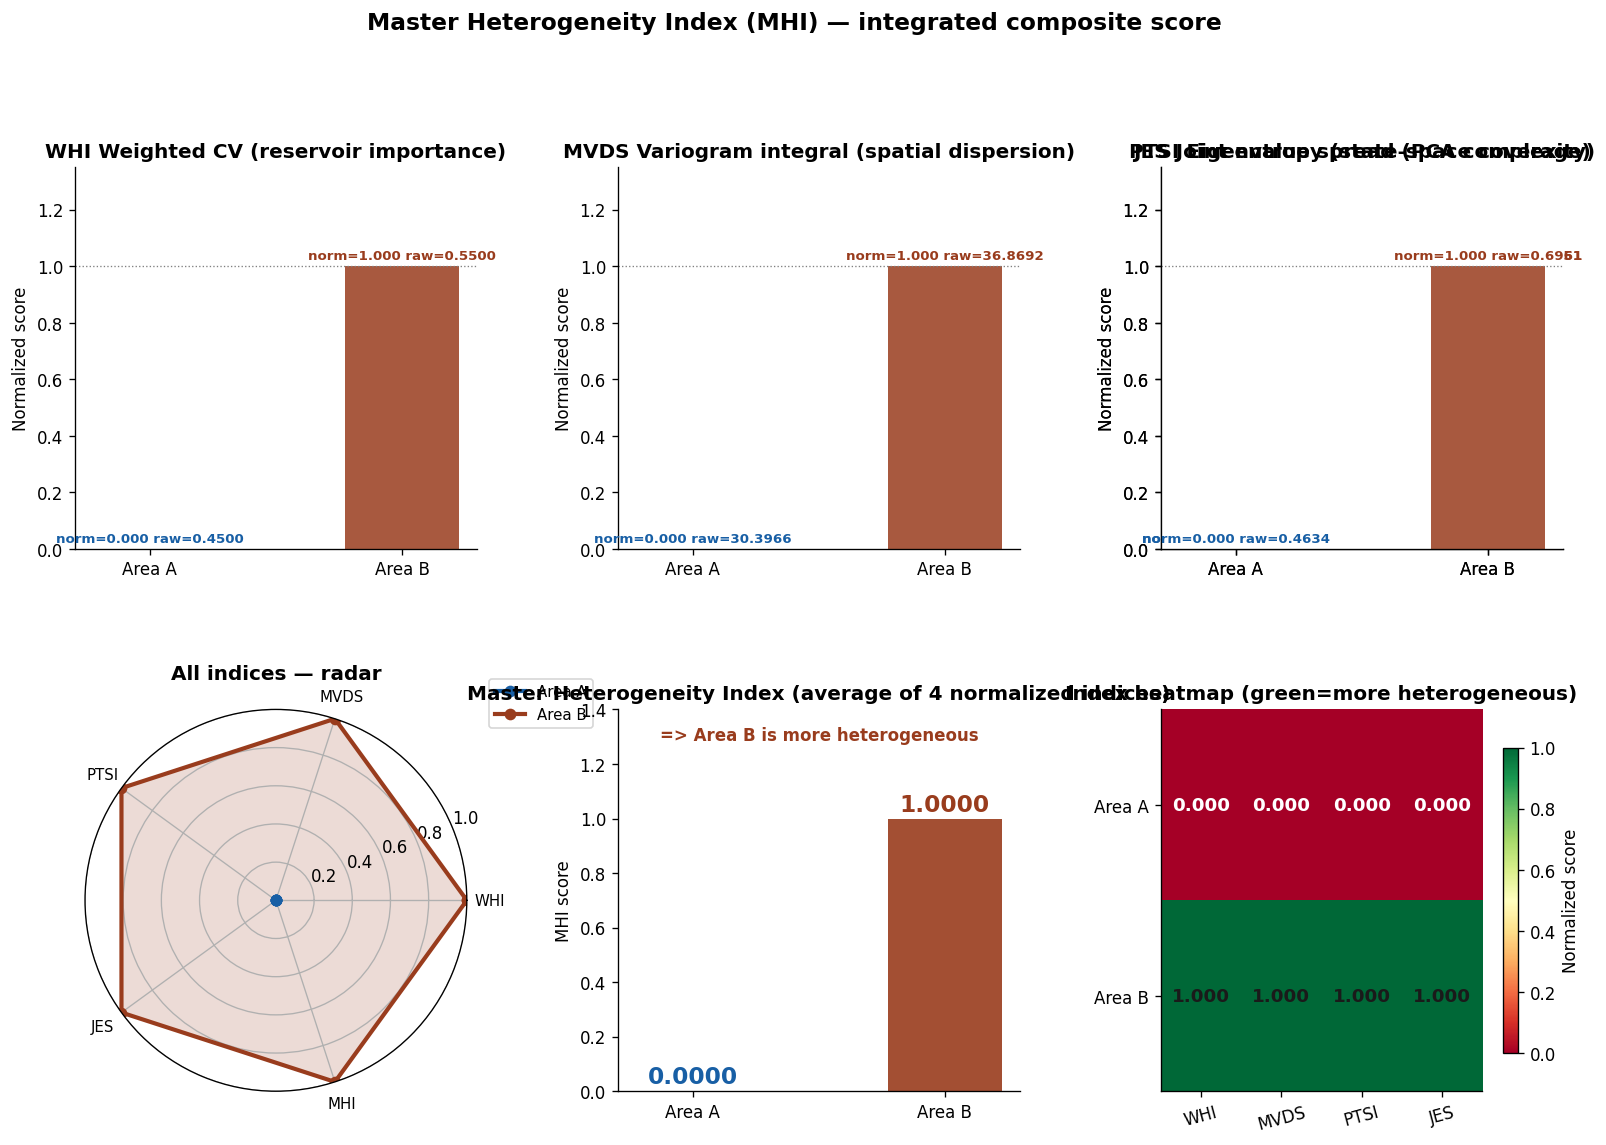

In [12]:
# ── Master dashboard figure ───────────────────────────────────────────────────
fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.42, wspace=0.35)

index_names  = ['WHI', 'MVDS', 'PTSI', 'JES']
raw_dicts    = [WHI, MVDS, PTSI, JES]
norm_dicts   = [WHI_n, MVDS_n, PTSI_n, JES_n]
descriptions = [
    'Weighted CV (reservoir importance)',
    'Variogram integral (spatial dispersion)',
    'Eigenvalue spread (PCA complexity)',
    'Joint entropy (state-space coverage)',
]

# ── Top row: individual index bars ────────────────────────────────────────────
for col, (name, raw, norm, desc) in enumerate(zip(index_names, raw_dicts, norm_dicts, descriptions)):
    ax = fig.add_subplot(gs[0, col] if col < 3 else gs[0, 2])
    vals = [norm[a] for a in AREAS]
    bars = ax.bar(AREAS, vals, color=[COLORS[a] for a in AREAS], alpha=0.85, width=0.45)
    for bar, area in zip(bars, AREAS):
        ax.text(bar.get_x()+bar.get_width()/2,
                bar.get_height()+0.015,
                f'norm={norm[area]:.3f} raw={raw[area]:.4f}',
                ha='center', va='bottom', fontsize=8, color=COLORS[area], fontweight='bold')
    ax.set_ylim(0, 1.35)
    ax.set_ylabel('Normalized score')
    ax.set_title(f'{name} {desc}', fontweight='bold')
    ax.axhline(1.0, color='gray', linestyle=':', linewidth=0.8)

# ── Bottom left: radar chart ──────────────────────────────────────────────────
ax_radar = fig.add_subplot(gs[1, 0], polar=True)
radar_labels = ['WHI', 'MVDS', 'PTSI', 'JES', 'MHI']
angles = np.linspace(0, 2*np.pi, len(radar_labels), endpoint=False).tolist()
angles += angles[:1]

mhi_n = norm2(MHI)
score_sets = {
    'Area A': [WHI_n['Area A'], MVDS_n['Area A'], PTSI_n['Area A'], JES_n['Area A'], mhi_n['Area A']],
    'Area B': [WHI_n['Area B'], MVDS_n['Area B'], PTSI_n['Area B'], JES_n['Area B'], mhi_n['Area B']],
}
for area, scores in score_sets.items():
    vals = scores + scores[:1]
    ax_radar.plot(angles, vals, 'o-', linewidth=2.5, color=COLORS[area], label=area)
    ax_radar.fill(angles, vals, alpha=0.18, color=COLORS[area])
ax_radar.set_thetagrids(np.degrees(angles[:-1]), radar_labels, fontsize=9)
ax_radar.set_ylim(0, 1)
ax_radar.set_title('All indices — radar', fontweight='bold', pad=18)
ax_radar.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=9)

# ── Bottom center: MHI final bar ──────────────────────────────────────────────
ax_mhi = fig.add_subplot(gs[1, 1])
mhi_vals = [MHI[a] for a in AREAS]
bars = ax_mhi.bar(AREAS, mhi_vals, color=[COLORS[a] for a in AREAS], alpha=0.9, width=0.45)
for bar, area in zip(bars, AREAS):
    ax_mhi.text(bar.get_x()+bar.get_width()/2,
                bar.get_height()+0.01,
                f'{MHI[area]:.4f}', ha='center', va='bottom',
                fontsize=14, fontweight='bold', color=COLORS[area])
ax_mhi.set_ylim(0, max(mhi_vals)*1.4)
ax_mhi.set_ylabel('MHI score')
ax_mhi.set_title('Master Heterogeneity Index (average of 4 normalized indices)', fontweight='bold')
winner = max(MHI, key=MHI.get)
ax_mhi.text(0.5, 0.92, f'=> {winner} is more heterogeneous',
            transform=ax_mhi.transAxes, ha='center', fontsize=10,
            color=COLORS[winner], fontweight='bold')

# ── Bottom right: index contribution heatmap ──────────────────────────────────
ax_heat = fig.add_subplot(gs[1, 2])
heat_data = np.array([[WHI_n[a], MVDS_n[a], PTSI_n[a], JES_n[a]] for a in AREAS])
im = ax_heat.imshow(heat_data, cmap='RdYlGn', vmin=0, vmax=1, aspect='auto')
ax_heat.set_xticks(range(4)); ax_heat.set_xticklabels(index_names, rotation=15)
ax_heat.set_yticks(range(2)); ax_heat.set_yticklabels(AREAS)
for i in range(2):
    for j in range(4):
        ax_heat.text(j, i, f'{heat_data[i,j]:.3f}', ha='center', va='center',
                     fontsize=11, fontweight='bold',
                     color='white' if heat_data[i,j] < 0.4 else '#1a1a1a')
plt.colorbar(im, ax=ax_heat, shrink=0.8, label='Normalized score')
ax_heat.set_title('Index heatmap (green=more heterogeneous)', fontweight='bold')

plt.suptitle('Master Heterogeneity Index (MHI) — integrated composite score',
             fontsize=14, fontweight='bold', y=1.01)
plt.savefig('MHI_master_dashboard.png', dpi=130, bbox_inches='tight')
plt.show()


---
## Spatial MHI map — where is heterogeneity concentrated?

While MHI gives one scalar per area, we can also compute a **node-wise MHI map**
by applying a moving-window version of each index at every spatial location.
This answers: *within each area, where is the heterogeneity highest?*


In [13]:
from scipy.ndimage import uniform_filter

def local_mhi_map(area_grids, window=9, n_bins=5):
    """
    Compute a spatial MHI map by applying local CV and local entropy
    in a moving window across the grid.
    Returns a 2-D array of shape (GRID+1, GRID+1).
    """
    shape = list(area_grids.values())[0].shape
    rows, cols = shape
    half = window // 2

    # Stack all property grids: shape (rows, cols, n_props)
    stack = np.stack([area_grids[p] for p in PROPS], axis=-1)

    # Normalize each property to [0,1] globally
    stack_n = np.zeros_like(stack)
    for j in range(stack.shape[-1]):
        lo, hi = stack[:,:,j].min(), stack[:,:,j].max()
        stack_n[:,:,j] = (stack[:,:,j] - lo) / (hi - lo + 1e-12)

    local_map = np.zeros((rows, cols), dtype=float)

    for r in range(rows):
        for c in range(cols):
            r0, r1 = max(0, r-half), min(rows, r+half+1)
            c0, c1 = max(0, c-half), min(cols, c+half+1)
            patch = stack_n[r0:r1, c0:c1, :]      # shape (wr, wc, 5)
            flat  = patch.reshape(-1, patch.shape[-1])  # (n_pixels, 5)

            # Local CV mean (normalized)
            cv_vals = flat.std(axis=0) / (np.abs(flat.mean(axis=0)) + 1e-12)
            local_cv_score = cv_vals.mean()

            # Local joint entropy
            if flat.shape[0] < 5:
                local_ent = 0.0
            else:
                binned = np.zeros_like(flat, dtype=int)
                for j in range(flat.shape[1]):
                    q = np.linspace(0, 100, n_bins+1)
                    edges = np.percentile(flat[:,j], q)
                    edges[0] -= 1e-10; edges[-1] += 1e-10
                    binned[:,j] = np.digitize(flat[:,j], edges[1:-1])
                combos = [tuple(row) for row in binned]
                from collections import Counter
                cnt = Counter(combos)
                total = sum(cnt.values())
                p = np.array(list(cnt.values())) / total
                local_ent = -np.sum(p * np.log2(p + 1e-12))
                local_ent /= (flat.shape[1] * np.log2(n_bins) + 1e-12)

            local_map[r, c] = 0.5*local_cv_score + 0.5*local_ent

    return local_map

print("Computing spatial MHI maps (this takes ~60 s)...")
spatial_mhi = {}
for area in AREAS:
    spatial_mhi[area] = local_mhi_map(grids[area], window=9)
    print(f"  {area} done  (mean={spatial_mhi[area].mean():.4f})")
print("Done.")


Computing spatial MHI maps (this takes ~60 s)...
  Area A done  (mean=0.3157)
  Area B done  (mean=0.3066)
Done.


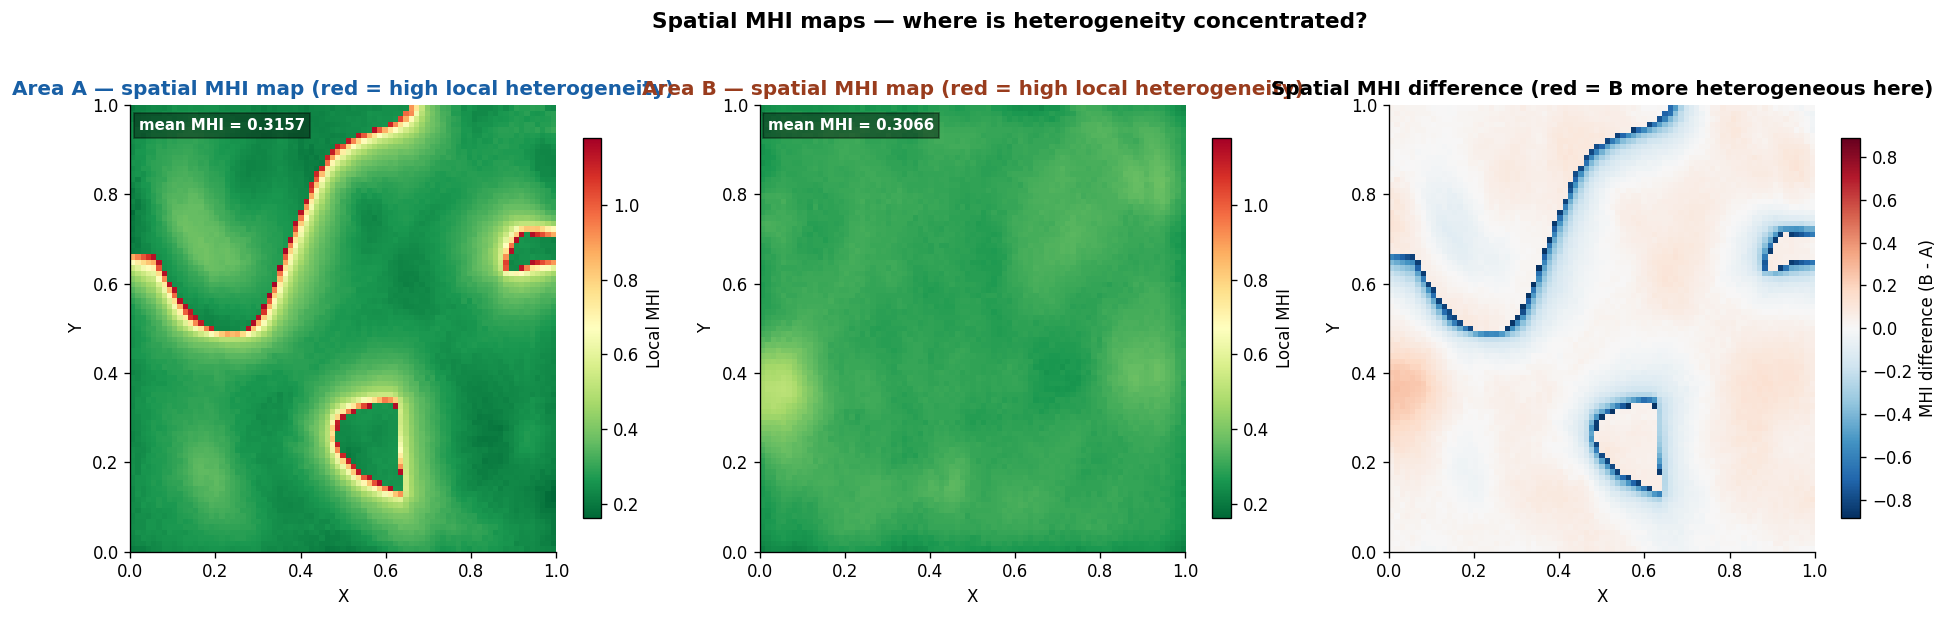

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

vmin = min(spatial_mhi[a].min() for a in AREAS)
vmax = max(spatial_mhi[a].max() for a in AREAS)

for col, area in enumerate(AREAS):
    ax = axes[col]
    im = ax.imshow(spatial_mhi[area], origin='lower', cmap='RdYlGn_r',
                   vmin=vmin, vmax=vmax, extent=[0,1,0,1], aspect='auto')
    plt.colorbar(im, ax=ax, shrink=0.85, label='Local MHI')
    ax.set_title(f'{area} — spatial MHI map (red = high local heterogeneity)',
                 fontweight='bold', color=COLORS[area])
    ax.set_xlabel('X'); ax.set_ylabel('Y')
    ax.text(0.02, 0.97, f'mean MHI = {spatial_mhi[area].mean():.4f}',
            transform=ax.transAxes, va='top', fontsize=9,
            color='white', fontweight='bold',
            bbox=dict(facecolor='black', alpha=0.4, pad=3))

# Difference map
ax3 = axes[2]
diff = spatial_mhi['Area B'] - spatial_mhi['Area A']
vd   = np.abs(diff).max()
im3  = ax3.imshow(diff, origin='lower', cmap='RdBu_r',
                  vmin=-vd, vmax=vd, extent=[0,1,0,1], aspect='auto')
plt.colorbar(im3, ax=ax3, shrink=0.85, label='MHI difference (B - A)')
ax3.set_title('Spatial MHI difference (red = B more heterogeneous here)',
              fontweight='bold')
ax3.set_xlabel('X'); ax3.set_ylabel('Y')

plt.suptitle('Spatial MHI maps — where is heterogeneity concentrated?',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('spatial_MHI_maps.png', dpi=130, bbox_inches='tight')
plt.show()


---
## Summary

| Index | Basis | Area A | Area B | More heterogeneous |
|-------|-------|--------|--------|-------------------|
| WHI | Weighted CV | — | — | see scorecard |
| MVDS | Variogram integral | — | — | see scorecard |
| PTSI | Eigenvalue spread | — | — | see scorecard |
| JES | Joint entropy | — | — | see scorecard |
| **MHI** | **Average of above** | — | — | **see scorecard** |

Run the scorecard cell above to populate the table with your computed values.

### When to use each index

| Scenario | Recommended index |
|----------|------------------|
| Quick screening, unit-aware properties | WHI |
| Spatial resolution matters (well spacing decisions) | MVDS |
| Understanding whether one geological process dominates | PTSI |
| Stochastic simulation design (SGS, MPS) | JES |
| Final ranking combining all evidence | MHI |
| Where to locate appraisal wells | Spatial MHI map |
